# 🔍 Fingerprint Matching Engine

This notebook demonstrates Phase 4: Matching Engine. It runs both classical minutiae matching (with heuristic descriptor-based alignment) and deep learning embedding similarity scoring.

In [1]:
import os
import sys
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torchvision import transforms

# Add project root to path
PROJECT_ROOT = Path(os.path.abspath('')).parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import preprocess
from src.feature_extraction import detect_minutiae, compute_descriptors, create_template
from src.feature_extraction.embedding import SiameseNetwork, extract_embedding
from src.matching import align_templates, match_minutiae, compute_minutiae_score, compute_embedding_score

DATA_DIR = PROJECT_ROOT / 'data' / 'raw' / 'SOCOFing'
MODEL_PATH = PROJECT_ROOT / 'models' / 'siamese_model.pth'

## 1. Helper Function for End-to-End Extraction

In [2]:
# Load Siamese Model
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
siamese_model = SiameseNetwork(embedding_dim=128, pretrained=False).to(device)
if MODEL_PATH.exists():
    siamese_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
siamese_model.eval()

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def extract_features(img_path):
    """Extracts both classical template and deep embedding for an image."""
    # 1. Classical
    pre = preprocess(str(img_path), return_intermediates=True)
    mins = detect_minutiae(pre['skeleton'], border_margin=15, min_distance=10, mask=pre['intermediates']['mask'])
    descs = compute_descriptors(pre['skeleton'], mins, radius=30, num_sectors=8)
    template = create_template(mins, descs)
    
    # 2. Deep Embedding
    img_cv = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_GRAY2RGB)
    tensor = transform(img_rgb)
    emb = extract_embedding(siamese_model, tensor, device).cpu().numpy()[0]
    
    return template, emb, img_cv

## 2. Evaluate a Genuine Pair

In [3]:
gen_p1 = DATA_DIR / 'Real' / '100__M_Left_index_finger.BMP'
gen_p2 = DATA_DIR / 'Altered' / 'Altered-Easy' / '100__M_Left_index_finger_CR.BMP'

t1, e1, img1 = extract_features(gen_p1)
t2, e2, img2 = extract_features(gen_p2)

# Classical Matching (t2 is probe, t1 is gallery)
aligned_t2, dx, dy, dtheta = align_templates(t2, t1)
matched_pairs = match_minutiae(aligned_t2, t1, spatial_tol=15.0, angular_tol=0.52) # ~30 deg
classical_score = compute_minutiae_score(matched_pairs, len(t2['minutiae']), len(t1['minutiae']))

# Deep Matching
deep_score = compute_embedding_score(e1, e2)

print("=== GENUINE PAIR ===")
print(f"Probe Minutiae: {len(t2['minutiae'])} | Gallery Minutiae: {len(t1['minutiae'])}")
print(f"Matched Pairs: {len(matched_pairs)}")
print(f"Classical Score: {classical_score:.3f}")
print(f"Deep Embedding Score: {deep_score:.3f}")

=== GENUINE PAIR ===
Probe Minutiae: 68 | Gallery Minutiae: 63
Matched Pairs: 58
Classical Score: 0.885
Deep Embedding Score: 0.981


## 3. Evaluate an Impostor Pair

In [4]:
imp_p1 = DATA_DIR / 'Real' / '100__M_Left_index_finger.BMP'
imp_p2 = DATA_DIR / 'Real' / '102__M_Left_index_finger.BMP'

t3, e3, img3 = extract_features(imp_p1)
t4, e4, img4 = extract_features(imp_p2)

aligned_t4, _, _, _ = align_templates(t4, t3)
matched_pairs_imp = match_minutiae(aligned_t4, t3, spatial_tol=15.0, angular_tol=0.52)
classical_score_imp = compute_minutiae_score(matched_pairs_imp, len(t4['minutiae']), len(t3['minutiae']))
deep_score_imp = compute_embedding_score(e3, e4)

print("\n=== IMPOSTOR PAIR ===")
print(f"Probe Minutiae: {len(t4['minutiae'])} | Gallery Minutiae: {len(t3['minutiae'])}")
print(f"Matched Pairs: {len(matched_pairs_imp)}")
print(f"Classical Score: {classical_score_imp:.3f}")
print(f"Deep Embedding Score: {deep_score_imp:.3f}")


=== IMPOSTOR PAIR ===
Probe Minutiae: 88 | Gallery Minutiae: 63
Matched Pairs: 3
Classical Score: 0.040
Deep Embedding Score: 0.937


## 4. Visualizing Results

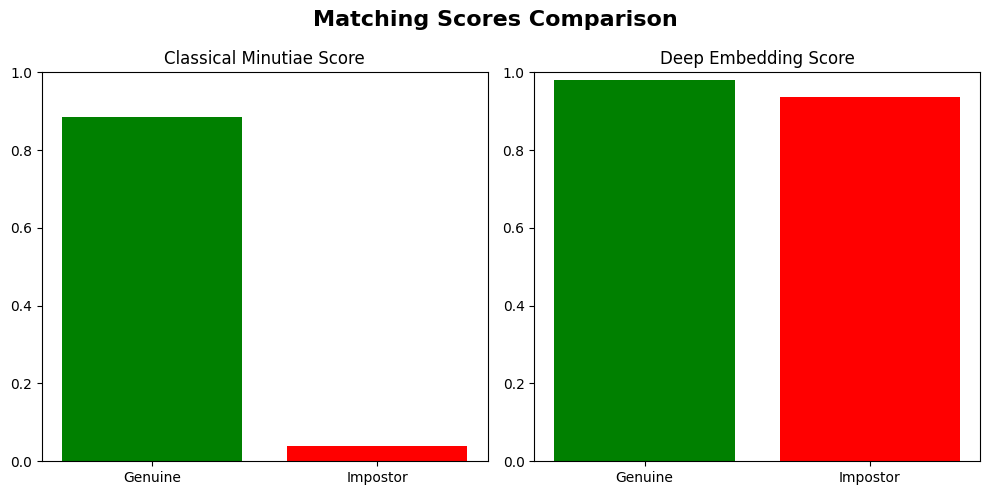

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Matching Scores Comparison", fontsize=16, fontweight='bold')

axes[0].bar(['Genuine', 'Impostor'], [classical_score, classical_score_imp], color=['green', 'red'])
axes[0].set_title("Classical Minutiae Score")
axes[0].set_ylim(0, 1.0)

axes[1].bar(['Genuine', 'Impostor'], [deep_score, deep_score_imp], color=['green', 'red'])
axes[1].set_title("Deep Embedding Score")
axes[1].set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'data' / 'matching_scores_comparison.png'), dpi=150)
plt.show()